WELFake

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Fake detction/data/WELFake_Dataset.csv')

In [ ]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
df.describe()

,Unnamed: 0,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
title,558
text,39
label,0


In [ ]:
df.shape

(72134, 4)

In [ ]:
list(df.columns)

['Unnamed: 0', 'title', 'text', 'label']

In [ ]:
df[df["text"].isnull()]

,Unnamed: 0,title,text,label
2457,2457,Après le succès de « Mariés au premier regard ...,NaN,1
3534,3534,Elections US : les premières estimations donne...,NaN,1
3709,3709,110% des Américains assurent qu’ils continuero...,NaN,1
5612,5612,Des millions d’Américains recherchent massivem...,NaN,1
6270,6270,Vladimir Poutine est élu 45e Président des Eta...,NaN,1
6997,6997,Les Américains ne sont plus qu’à quelques heur...,NaN,1
7083,7083,Gorafi Magazine: Barack Obama « Je vous ai déj...,NaN,1
8974,8974,Live Soirée présidentielle US 2016 >> Le Gorafi,NaN,1
16717,16717,Ne supportant plus l’ambiance de la campagne é...,NaN,1
17781,17781,Débat Primaire de la Droite : les Français pas...,NaN,1


2. Dataset Inspection

In [ ]:
# Display first five rows
print("=" * 70)
print("First Five Records")
display(df.head())

# Dataset dimensions
print("=" * 70)
print("Dataset Shape")
print(df.shape)

# Column names
print("=" * 70)
print("Column Names")
print(df.columns.tolist())

# Dataset information
print("=" * 70)
print("Dataset Information")
df.info()

# Missing values
print("=" * 70)
print("Missing Values")
display(df.isnull().sum().to_frame(name="Missing Values"))

# Statistical summary (Numerical)
print("=" * 70)
print("Numerical Summary")
display(df.describe())

# Statistical summary (Text Columns)
print("=" * 70)
print("Categorical/Text Summary")
display(df.describe(include='object'))

First Five Records


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


Dataset Shape
(72134, 4)
Column Names
['Unnamed: 0', 'title', 'text', 'label']
Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB
Missing Values


,Missing Values
Unnamed: 0,0
title,558
text,39
label,0


Numerical Summary


,Unnamed: 0,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


Categorical/Text Summary


,title,text
count,71576,72095
unique,62347,62718
top,Factbox: Trump fills top jobs for his administ...,
freq,14,738


3. Data Quality Assessment

In [ ]:
# ==========================
# Duplicate Records
# ==========================
print("="*70)
print("Duplicate Rows")
print(df.duplicated().sum())

# ==========================
# Class Distribution
# ==========================
print("="*70)
print("Class Distribution")
display(df["label"].value_counts())

display(
    round(df["label"].value_counts(normalize=True)*100,2)
    .rename("Percentage")
    .to_frame()
)

# ==========================
# Missing Value Percentage
# ==========================
print("="*70)
print("Missing Value Percentage")

missing_percentage = (
    df.isnull().sum()/len(df)*100
).round(2)

display(missing_percentage.to_frame(name="Percentage"))

# ==========================
# Unique Values
# ==========================
print("="*70)
print("Unique Values")

display(df.nunique().to_frame(name="Unique Count"))

Duplicate Rows
0
Class Distribution


,count
label,
1,37106
0,35028


,Percentage
label,
1,51.44
0,48.56


Missing Value Percentage


,Percentage
Unnamed: 0,0.00
title,0.77
text,0.05
label,0.00


Unique Values


,Unique Count
Unnamed: 0,72134
title,62347
text,62718
label,2


3.5 Duplicate Content Investigation

In [ ]:
print("="*70)
print("Duplicate Investigation")

# Duplicate Titles
duplicate_titles = df["title"].duplicated().sum()

# Duplicate Text
duplicate_texts = df["text"].duplicated().sum()

# Duplicate Title + Text
duplicate_news = df.duplicated(subset=["title", "text"]).sum()

print(f"Duplicate Titles      : {duplicate_titles}")
print(f"Duplicate Texts       : {duplicate_texts}")
print(f"Duplicate News Pairs  : {duplicate_news}")

Duplicate Investigation
Duplicate Titles      : 9786
Duplicate Texts       : 9415
Duplicate News Pairs  : 8456


Duplicate Label Consistency Check

In [ ]:
duplicate_groups = (
    df.groupby(["title", "text"])["label"]
      .nunique()
      .reset_index(name="unique_labels")
)

conflicting_duplicates = duplicate_groups[
    duplicate_groups["unique_labels"] > 1
]

print("=" * 70)
print("Conflicting Duplicate News")

print("Number of conflicting duplicate articles:",
      len(conflicting_duplicates))


duplicate_groups.tail()

Conflicting Duplicate News
Number of conflicting duplicate articles: 0


,title,text,unique_labels
63116,„Es hat sich wie ein Virus verbreitet“: Wie Po...,10 870 0 26 In den teilweise erschütternden Be...,1
63117,„Reichsbürger“ schlagen zu – Sind Beamte für R...,22 1655 6 24 Gleich mehrere Polizisten in Baye...,1
63118,„The Duelist“: Martins Wuttkes neuer Tatort,"film , deutschland und russland Der neue Film ...",1
63119,俄罗斯总统观注,安理会28日会议2016年十月\n俄罗斯总统观注 伏尔泰网 | 纽约（美国） | 2016年...,1
63120,🚨Bill Clinton and Hillary Lolita Express Pedop...,🚨Bill Clinton and Hillary Lolita Express Pedop...,1


4.1 Language Distribution Analysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


,Count
language,
en,4903
unknown,59
ru,14
es,6
de,6
fr,3
tl,3
tr,2
sw,2


,Percentage
language,
en,98.06
unknown,1.18
ru,0.28
es,0.12
de,0.12
fr,0.06
tl,0.06
tr,0.04
sw,0.04


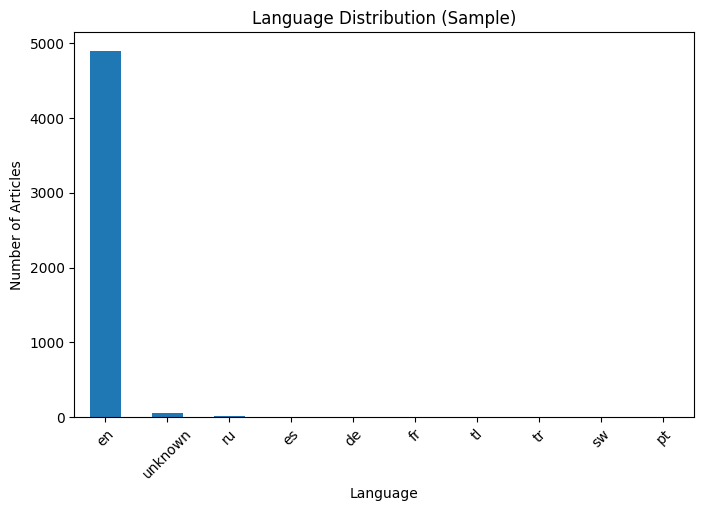

In [ ]:
# Step 1 — Install Language Detection Library
!pip -q install langdetect

# Step 2 — Detect Language
from langdetect import detect
from langdetect import DetectorFactory

DetectorFactory.seed = 42

def detect_language(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

sample_df = df.sample(5000, random_state=42).copy()

sample_df["language"] = sample_df["text"].apply(detect_language)


# Step 3 — Count Languages
language_counts = (
    sample_df["language"]
    .value_counts()
)

language_percentage = (
    sample_df["language"]
    .value_counts(normalize=True) * 100
).round(2)

display(language_counts.to_frame(name="Count"))
display(language_percentage.to_frame(name="Percentage"))


# Step 4 — Visualization
import matplotlib.pyplot as plt

language_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Language Distribution (Sample)")
plt.xlabel("Language")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.show()

4.2 Investigation of Unknown Language Articles

In [ ]:
# Filter unknown language articles
unknown_articles = sample_df[sample_df["language"] == "unknown"]

print(f"Total Unknown Articles: {len(unknown_articles)}")

# Display 10 random samples
display(
    unknown_articles[
        ["title", "text"]
    ].sample(
        min(10, len(unknown_articles)),
        random_state=42
    )
)

Total Unknown Articles: 59


,title,text
61370,ARNOLD SCHWARZENEGGER Sends A Message To Liber...,
12111,HECKLERS YELL: “Bill Clinton’s a rapist!” At M...,
51487,OUR CRYBABY COMMUNITY ORGANIZER Makes A Fool O...,
57698,WATCH KELLYANNE CONWAY vs Total Jerk Chris Cuo...,https://www.youtube.com/watch?v=6VN1maBEKIk
23151,Southern Poverty Law Center Targets Anti-Jihad...,
54773,FATHER OF BENGHAZI VICTIM TY WOODS SPEAKS UP A...,
14832,SARA CARTER WAS RIGHT ABOUT SPYING ON TRUMP! “...,https://www.youtube.com/watch?v=Ws5ojb0PCCo
23543,KELLYANNE CONWAY On Trump’s Terrorism Policy: ...,https://www.youtube.com/watch?v=0cVugq2GbBk
60111,OUTRAGEOUS VIDEO! OBAMA KEEPS STIRRING THE FLA...,
53874,ROB SCHNEIDER Nails The Russia Conspiracy Theo...,


4.3 Feature Engineering for Exploratory Data Analysis

In [ ]:
# ==========================================
# Feature Engineering for EDA
# ==========================================

# Fill missing values temporarily for analysis
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")

# Character-based features
df["title_length"] = df["title"].str.len()
df["text_length"] = df["text"].str.len()

# Word-based features
df["title_word_count"] = df["title"].str.split().str.len()
df["text_word_count"] = df["text"].str.split().str.len()

# Combined feature
df["total_word_count"] = (
    df["title_word_count"] +
    df["text_word_count"]
)

print("=" * 70)
print("EDA Features Created Successfully")

display(
    df[
        [
            "title_length",
            "text_length",
            "title_word_count",
            "text_word_count",
            "total_word_count"
        ]
    ].head()
)

EDA Features Created Successfully


,title_length,text_length,title_word_count,text_word_count,total_word_count
0,130,5049,18,871,889
1,0,46,0,8,8
2,137,216,18,34,52
3,105,8010,16,1321,1337
4,95,1916,16,329,345


4.4 Target Variable Analysis

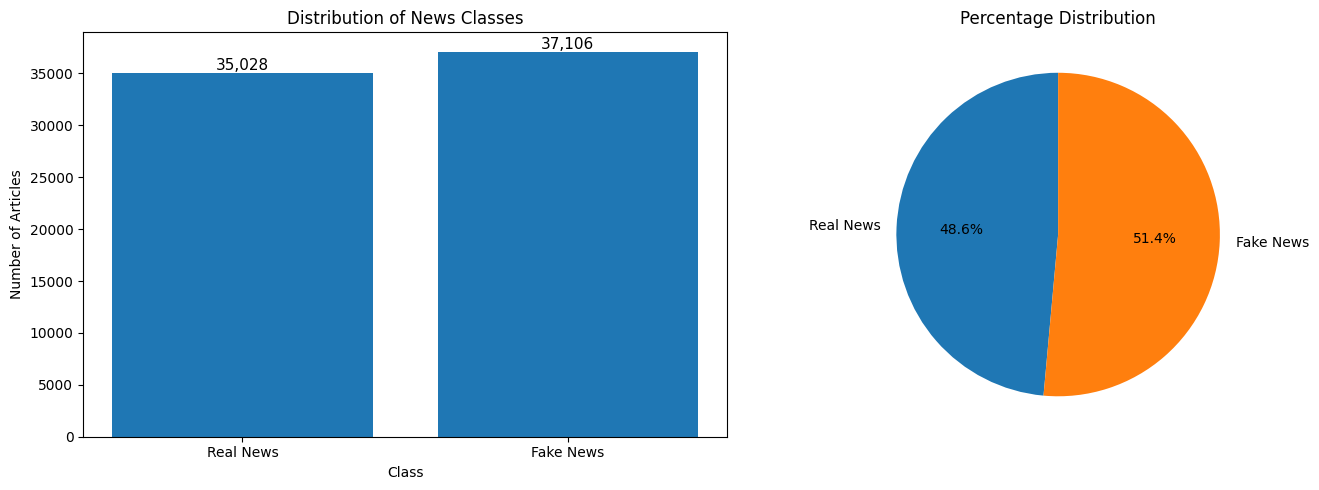

In [ ]:
import matplotlib.pyplot as plt

# Count labels
class_counts = df["label"].value_counts().sort_index()

# Label mapping
label_names = {
    0: "Real News",
    1: "Fake News"
}

labels = [label_names[i] for i in class_counts.index]
counts = class_counts.values

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------
# Bar Chart
# ------------------------

bars = ax[0].bar(labels, counts)

ax[0].set_title("Distribution of News Classes")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Number of Articles")

# Add values above bars
for bar in bars:
    height = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# ------------------------
# Pie Chart
# ------------------------

ax[1].pie(
    counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

ax[1].set_title("Percentage Distribution")

plt.tight_layout()
plt.show()

4.5 Title Length Analysis

/tmp/ipykernel_1886/3768910891.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Real News", "Fake News"])


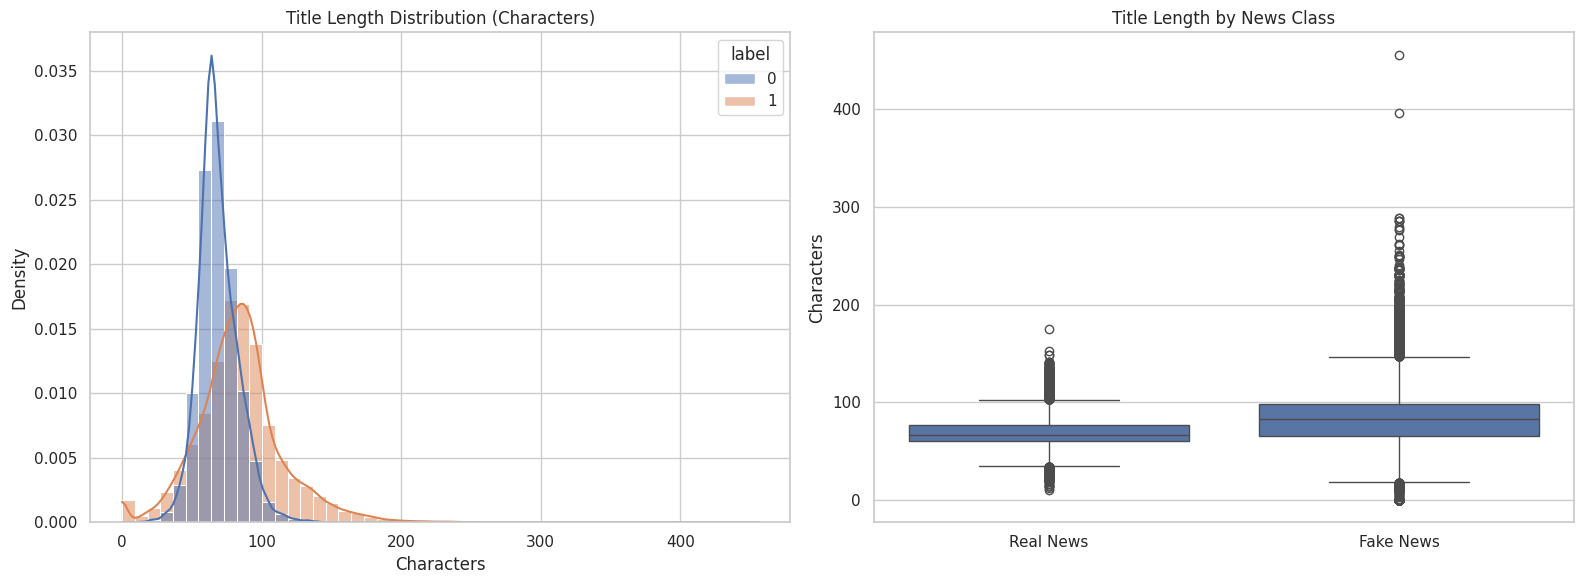

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Better plot style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =========================================
# Character Length Distribution
# =========================================
sns.histplot(
    data=df,
    x="title_length",
    hue="label",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False,
    ax=axes[0]
)

axes[0].set_title("Title Length Distribution (Characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Density")

# =========================================
# Box Plot
# =========================================0
sns.boxplot(
    data=df,
    x="label",
    y="title_length",
    ax=axes[1]
)

axes[1].set_xticklabels(["Real News", "Fake News"])
axes[1].set_title("Title Length by News Class")
axes[1].set_xlabel("")
axes[1].set_ylabel("Characters")

plt.tight_layout()
plt.show()

In [ ]:
# 💻 Summary Statistics
title_stats = (
    df.groupby("label")[
        ["title_length", "title_word_count"]
    ]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

display(title_stats)

title_length                 title_word_count               
              mean median min  max             mean median min max
label                                                             
0            68.79   67.0  10  175            11.05   11.0   2  30
1            83.86   83.0   0  456            13.24   13.0   0  72

4.6 Article Length Analysis

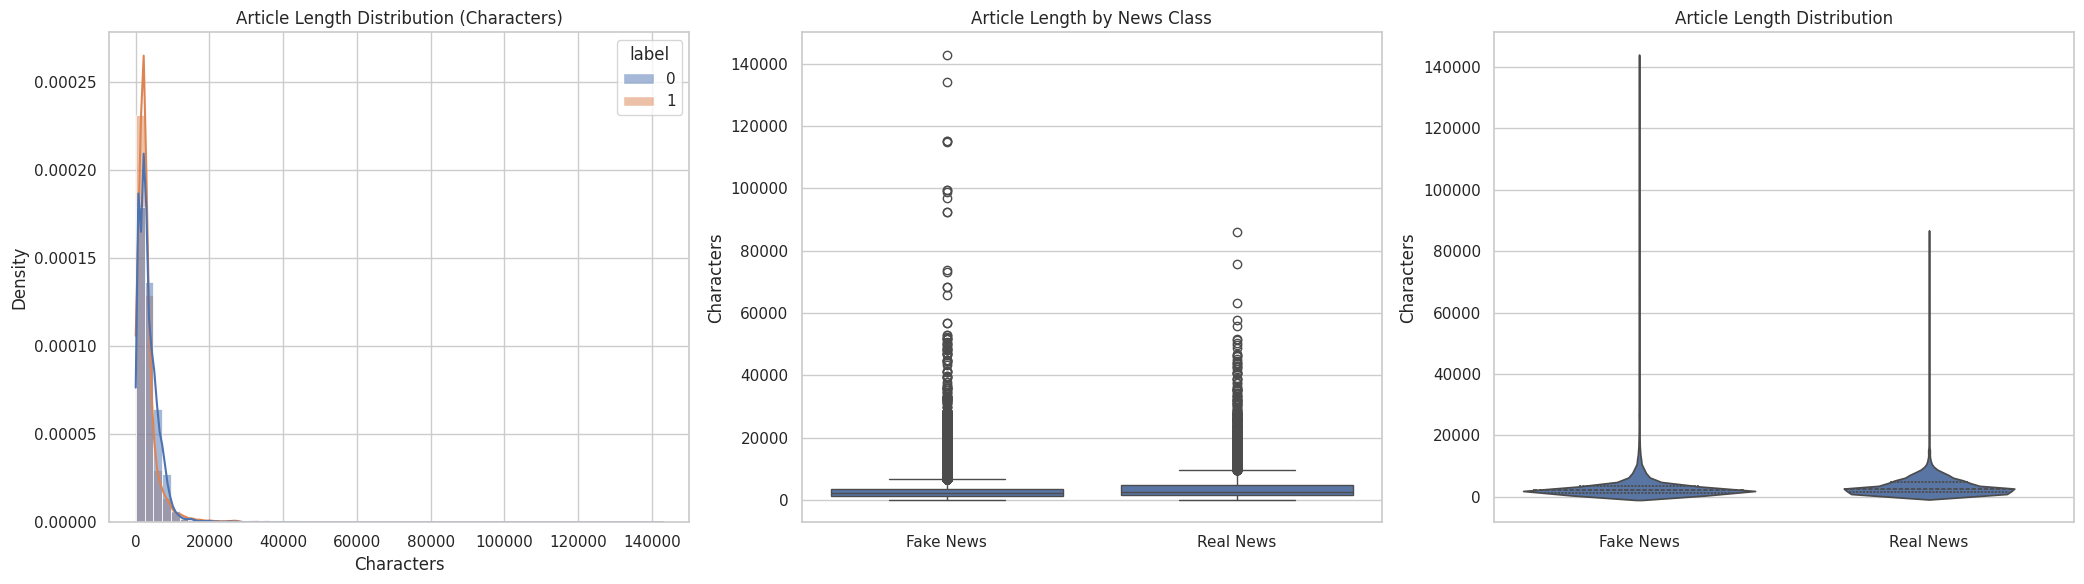

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(21,6))

# =====================================
# Histogram
# =====================================

sns.histplot(
    data=df,
    x="text_length",
    hue="label",
    bins=60,
    kde=True,
    stat="density",
    common_norm=False,
    ax=axes[0]
)

axes[0].set_title("Article Length Distribution (Characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Density")

# =====================================
# Boxplot
# =====================================

sns.boxplot(
    data=df,
    x=df["label"].map({0:"Real News",1:"Fake News"}),
    y="text_length",
    ax=axes[1]
)

axes[1].set_title("Article Length by News Class")
axes[1].set_xlabel("")
axes[1].set_ylabel("Characters")

# =====================================
# Violin Plot
# =====================================

sns.violinplot(
    data=df,
    x=df["label"].map({0:"Real News",1:"Fake News"}),
    y="text_length",
    inner="quartile",
    ax=axes[2]
)

axes[2].set_title("Article Length Distribution")
axes[2].set_xlabel("")
axes[2].set_ylabel("Characters")

plt.tight_layout()
plt.show()

In [ ]:
# 📊 Summary Statistics
text_stats = (
    df.groupby("label")[
        ["text_length","text_word_count"]
    ]
    .agg(
        ["mean","median","std","min","max"]
    )
    .round(2)
)

display(text_stats)

text_length                              text_word_count                 \
             mean  median      std min     max            mean median     std   
label                                                                           
0         3495.32  2642.5  3325.50   1   85948          577.62  427.0  563.12   
1         3054.17  2210.0  4068.74   0  142961          505.56  369.0  677.12   

                  
      min    max  
label             
0       0  14641  
1       0  24234

4.7 Outlier Investigation

In [ ]:
# ==========================================
# Top 10 Longest Articles
# ==========================================

longest_articles = (
    df.sort_values("text_word_count", ascending=False)
      .loc[:, [
          "title",
          "label",
          "text_word_count",
          "text_length",
          "text"
      ]]
      .head(10)
)

display(longest_articles)





# This makes inspection easier.


for i, row in longest_articles.iterrows():

    print("="*100)

    print(f"Article {i}")

    print(f"Label       : {'Fake News' if row['label']==1 else 'Real News'}")

    print(f"Word Count  : {row['text_word_count']}")

    print(f"Characters  : {row['text_length']}")

    print("\nTitle:")
    print(row["title"])

    print("\nFirst 600 Characters:")
    print(row["text"][:600])

    print("\n")

,title,label,text_word_count,text_length,text
327,Re: The Hard Working American vs. The Governme...,1,24234,134206,The Hard Working American vs. The Government P...
54433,Re: Why Are So Many People Choosing To Leave T...,1,20891,115372,Why Are So Many People Choosing To Leave The U...
34523,Re: Why Are So Many People Choosing To Leave T...,1,20891,115372,Why Are So Many People Choosing To Leave The U...
6445,Заседание Международного дискуссионного клуба ...,1,20876,142961,Заседание Международного дискуссионного клуба ...
17557,Re: How Many People Will Have To Migrate Out O...,1,20084,115010,How Many People Will Have To Migrate Out Of Ca...
71687,Re: 55 Reasons Why California Is The Worst Sta...,1,17427,98698,55 Reasons Why California Is The Worst State I...
37058,Re: It Is Now Mathematically Impossible To Pay...,1,17332,99355,It Is Now Mathematically Impossible To Pay Off...
30636,Re: It Is Now Mathematically Impossible To Pay...,1,17332,99355,It Is Now Mathematically Impossible To Pay Off...
63829,Re: Why Is Obama Threatening Russia With World...,1,17201,96869,Why Is Obama Threatening Russia With World War...
14398,Benny Morris’s Untenable Denial of the Ethnic ...,1,15199,92561,References The Debate \nIt started when Daniel...


Article 327
Label       : Fake News
Word Count  : 24234
Characters  : 134206

Title:
Re: The Hard Working American vs. The Government Parasite

First 600 Characters:
The Hard Working American vs. The Government Parasite By Michael Snyder, on April 10th, 2012 
Which lifestyle choice produces better results – being a hard working American or being a government parasite? Actually, when you look at the cold, hard numbers they may just surprise you. In America today, we deeply penalize hard work and we greatly reward government dependence. If you live in a very liberal area of the country and you know how to game the system, it is entirely possible to live a comfortable existence without ever working too much at all. In fact, there are some Americans that have 


Article 54433
Label       : Fake News
Word Count  : 20891
Characters  : 115372

Title:
Re: Why Are So Many People Choosing To Leave The United States Permanently?

First 600 Characters:
Why Are So Many People Choosing To Leave The 

4.8 Text Exploration

In [ ]:
# Section 4.8.1 – Create Clean Text for EDA

import re
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))



# Cleaning Function
def clean_text_for_eda(text):

    text = str(text).lower()

    # remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # remove numbers
    text = re.sub(r"\d+", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # remove stopwords
    words = [
        word
        for word in text.split()
        if word not in stop_words
    ]

    return " ".join(words)



# Apply
df["clean_text_eda"] = df["text"].apply(clean_text_for_eda)

print("EDA Text Created Successfully!")

display(
    df[
        ["text", "clean_text_eda"]
    ].head(3)
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


EDA Text Created Successfully!


,text,clean_text_eda
0,No comment is expected from Barack Obama Membe...,comment expected barack obama members fyf fuky...
1,Did they post their votes for Hillary already?,post votes hillary already
2,"Now, most of the demonstrators gathered last ...",demonstrators gathered last night exercising c...


4.8.2 Most Frequent Words

,word,count
134331,trump,106894
114348,said,49709
97843,people,48674
93317,one,45949
23465,clinton,45402
145446,would,43104
102439,president,39060
138327,us,34780
75884,like,31782
58349,hillary,31613


,word,count
92929,said,184607
110265,trump,107200
70673,mr,66091
118605,would,62514
83778,president,51301
76300,one,42823
73230,new,42528
79987,people,41792
101993,state,38870
3264,also,36609


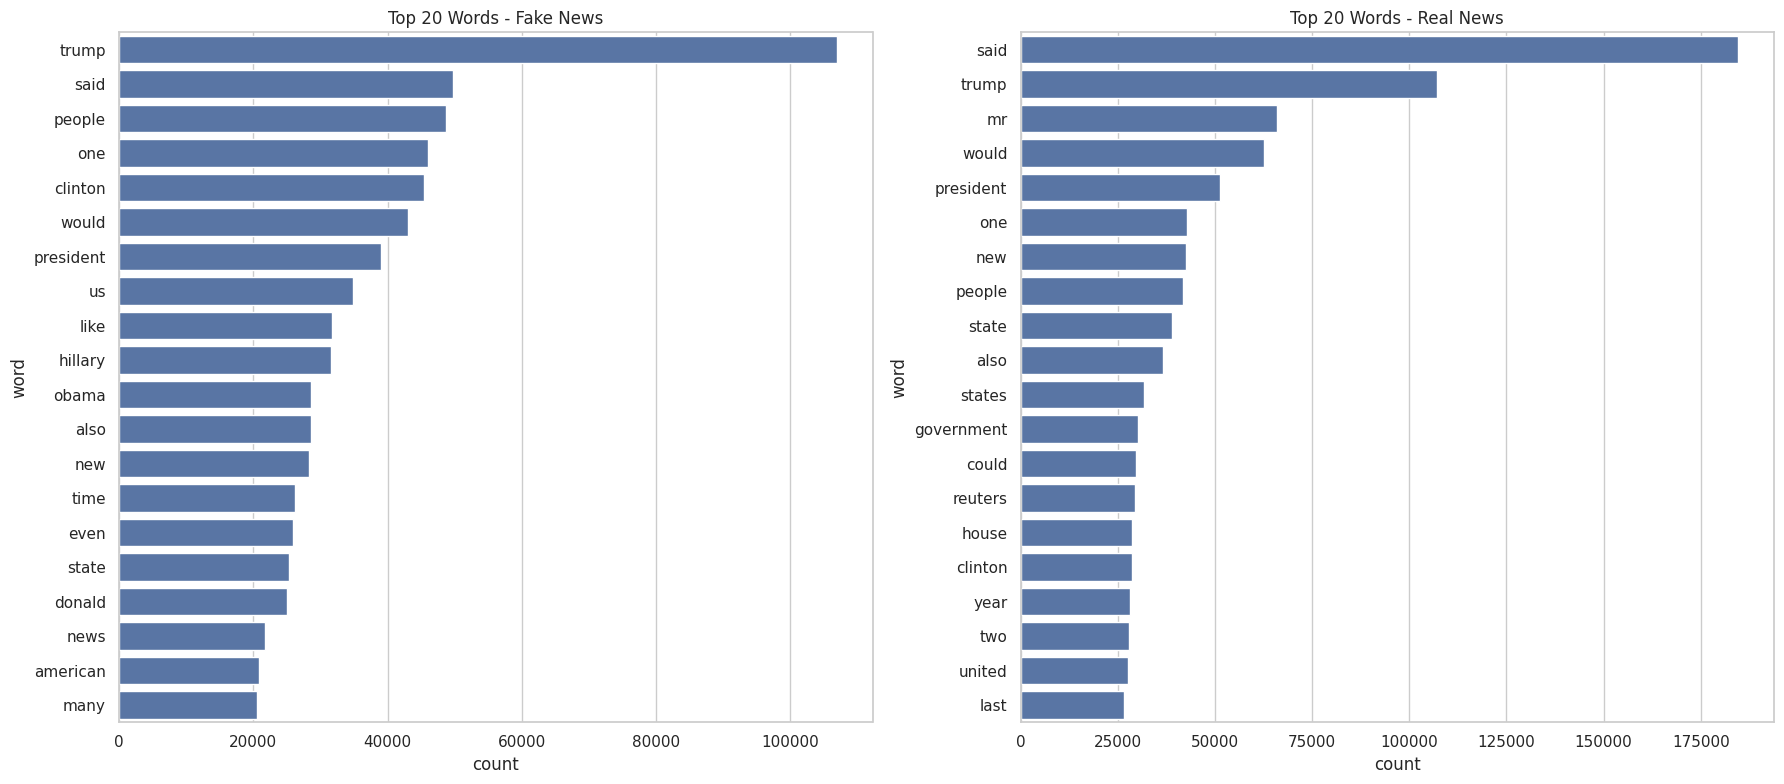

In [ ]:


from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_words(corpus, n=20):

    vectorizer = CountVectorizer()

    X = vectorizer.fit_transform(corpus)

    word_counts = X.sum(axis=0).A1

    words = vectorizer.get_feature_names_out()

    freq = pd.DataFrame({
        "word": words,
        "count": word_counts
    })

    return freq.sort_values(
        by="count",
        ascending=False
    ).head(n)



    # Generate Top Words

fake_top_words = get_top_words(
    df[df["label"] == 1]["clean_text_eda"]
)

real_top_words = get_top_words(
    df[df["label"] == 0]["clean_text_eda"]
)

display(fake_top_words)

display(real_top_words)


# Plot

fig, axes = plt.subplots(1, 2, figsize=(18,8))

sns.barplot(
    data=fake_top_words,
    y="word",
    x="count",
    ax=axes[0]
)

axes[0].set_title("Top 20 Words - Fake News")

sns.barplot(
    data=real_top_words,
    y="word",
    x="count",
    ax=axes[1]
)

axes[1].set_title("Top 20 Words - Real News")

plt.tight_layout()
plt.show()

Next: Section 4.9 - Word Cloud

In [ ]:
# !pip -q install wordcloud

# from wordcloud import WordCloud
# import matplotlib.pyplot as plt

# fake_text = " ".join(df[df["label"] == 1]["clean_text_eda"])

# real_text = " ".join(df[df["label"] == 0]["clean_text_eda"])

# fig, axes = plt.subplots(1,2, figsize=(18,8))

# # Fake News
# wc_fake = WordCloud(
#     width=800,
#     height=400,
#     background_color="white"
# ).generate(fake_text)

# axes[0].imshow(wc_fake)
# axes[0].axis("off")
# axes[0].set_title("Fake News WordCloud")

# # Real News
# wc_real = WordCloud(
#     width=800,
#     height=400,
#     background_color="white"
# ).generate(real_text)

# axes[1].imshow(wc_real)
# axes[1].axis("off")
# axes[1].set_title("Real News WordCloud")

# plt.tight_layout()
# plt.show()





4.10 Top Bigrams

In [ ]:
# from sklearn.feature_extraction.text import CountVectorizer
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# def get_top_ngrams(corpus, ngram_range=(2,2), top_n=20):

#     vectorizer = CountVectorizer(ngram_range=ngram_range)

#     X = vectorizer.fit_transform(corpus)

#     counts = X.sum(axis=0).A1

#     words = vectorizer.get_feature_names_out()

#     df_ngram = pd.DataFrame({
#         "ngram": words,
#         "count": counts
#     })

#     return df_ngram.sort_values(
#         "count",
#         ascending=False
#     ).head(top_n)





# # Generate Bigrams

# fake_bigrams = get_top_ngrams(
#     df[df["label"]==1]["clean_text_eda"]
# )

# real_bigrams = get_top_ngrams(
#     df[df["label"]==0]["clean_text_eda"]
# )

# # Plot

# fig, axes = plt.subplots(1,2, figsize=(18,8))

# sns.barplot(
#     data=fake_bigrams,
#     y="ngram",
#     x="count",
#     ax=axes[0]
# )

# axes[0].set_title("Top 20 Bigrams - Fake News")

# sns.barplot(
#     data=real_bigrams,
#     y="ngram",
#     x="count",
#     ax=axes[1]
# )

# axes[1].set_title("Top 20 Bigrams - Real News")

# plt.tight_layout()
# plt.show()





Top Trigrams

In [ ]:
# fake_trigrams = get_top_ngrams(
#     df[df["label"]==1]["clean_text_eda"],
#     ngram_range=(3,3)
# )

# real_trigrams = get_top_ngrams(
#     df[df["label"]==0]["clean_text_eda"],
#     ngram_range=(3,3)
# )




# # Plot

# fig, axes = plt.subplots(1,2, figsize=(18,8))

# sns.barplot(
#     data=fake_trigrams,
#     y="ngram",
#     x="count",
#     ax=axes[0]
# )

# axes[0].set_title("Top 20 trigrams - Fake News")

# sns.barplot(
#     data=real_trigrams,
#     y="ngram",
#     x="count",
#     ax=axes[1]
# )

# axes[1].set_title("Top 20 trigrams - Real News")

# plt.tight_layout()
# plt.show()

EDA Summary & Key Insights
The WELFake dataset contains 72,134 news articles with four columns: title, text, label, and an index column (Unnamed: 0).

The dataset is well balanced, containing approximately 51.4% fake news and 48.6% real news, making it suitable for binary classification.

Missing values are minimal (558 in title and 39 in text), indicating that only a small amount of preprocessing is required.

No completely duplicate rows were found; however, duplicate titles and articles exist, which will be handled during preprocessing.

Language analysis showed that approximately 98% of the sampled articles are in English, while only a very small fraction belongs to other languages. Therefore, the dataset is predominantly English.

Fake news articles generally have longer titles, whereas real news articles tend to have slightly longer article bodies on average.

Both classes contain several very long articles (outliers), but these represent valid news reports rather than data errors.

Word frequency analysis revealed that the dataset is heavily dominated by political news, with terms such as Trump, Clinton, Obama, and President appearing frequently.

Bigram and trigram analysis highlighted meaningful phrases such as Donald Trump, White House, United States, and President Donald Trump, showing that contextual information is more informative than individual words.

The strong overlap in vocabulary between fake and real news indicates that simple keyword-based approaches may not be sufficient, motivating the use of contextual deep learning models such as RoBERTa.

Based on the EDA findings, the next step is to perform data preprocessing and prepare separate pipelines for Machine Learning (TF-IDF based) and Deep Learning (RoBERTa based) models.

5.1 Data Cleaning & Preparation

In [ ]:
# ============================================================
# Data Cleaning & Preparation
# ============================================================

# Create a copy to preserve the original dataset
df_clean = df.copy()

# Drop unnecessary index column
df_clean.drop(columns=["Unnamed: 0"], inplace=True)

# Fill missing values
df_clean["title"] = df_clean["title"].fillna("")
df_clean["text"] = df_clean["text"].fillna("")

# Merge title and text
df_clean["combined_text"] = (
    df_clean["title"].str.strip()
    + " "
    + df_clean["text"].str.strip()
)

# Remove extra spaces
df_clean["combined_text"] = (
    df_clean["combined_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Remove duplicate articles
before = len(df_clean)

df_clean.drop_duplicates(
    subset=["combined_text"],
    inplace=True
)

after = len(df_clean)

print("="*70)
print("Data Cleaning Summary")
print("="*70)

print(f"Rows Before Cleaning : {before}")
print(f"Rows After Cleaning  : {after}")
print(f"Duplicates Removed   : {before-after}")

print("\nFinal Shape")
print(df_clean.shape)

print("\nColumns")
print(df_clean.columns.tolist())

print("\nSample Combined Text")
# Keep only the required columns
df_clean = df_clean[
    [
        "combined_text",
        "label"
    ]
]

print(df_clean.shape)
display(df_clean.head())

Data Cleaning Summary
Rows Before Cleaning : 72134
Rows After Cleaning  : 63673
Duplicates Removed   : 8461

Final Shape
(63673, 10)

Columns
['title', 'text', 'label', 'title_length', 'text_length', 'title_word_count', 'text_word_count', 'total_word_count', 'clean_text_eda', 'combined_text']

Sample Combined Text
(63673, 2)


,combined_text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1


5.2 NLP Text Cleaning

In [ ]:
# ============================================================
# Import Libraries
# ============================================================

import re
import nltk

from bs4 import BeautifulSoup
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# Download required resources
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")   # for newer NLTK versions

# Initialize objects
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


# ============================================================
# Text Cleaning Function
# ============================================================



# Convert NLTK POS tags to WordNet POS tags

def get_wordnet_pos(tag):

    if tag.startswith("J"):
        return wordnet.ADJ

    elif tag.startswith("V"):
        return wordnet.VERB

    elif tag.startswith("N"):
        return wordnet.NOUN

    elif tag.startswith("R"):
        return wordnet.ADV

    else:
        return wordnet.NOUN





def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove Twitter mentions
    text = re.sub(r"@\w+", " ", text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove [VIDEO], [PHOTO], etc.
    text = re.sub(r"\[.*?\]", " ", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # POS tagging
    tagged_words = pos_tag(words)

    # POS-aware Lemmatization
    words = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_words
    ]

    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Apply Text Cleaning

In [ ]:
# ============================================================
# Apply Cleaning Function
# ============================================================

print("Cleaning text... This may take a few minutes.")

df_clean["clean_text"] = df_clean["combined_text"].apply(clean_text)

print("\nCleaning Completed Successfully!")

display(
    df_clean[
        ["combined_text", "clean_text"]
    ].head(3)
)

Cleaning text... This may take a few minutes.

Cleaning Completed Successfully!


,combined_text,clean_text
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement high alert follow threat cop w...
1,Did they post their votes for Hillary already?,post vote hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obama attorney general say charlo...


In [ ]:
df_clean["clean_text"] = df_clean["clean_text"].str.strip()

Final Dataset Summary

In [ ]:
# ============================================================
# Final Preprocessed Dataset Summary
# ============================================================

print("=" * 70)
print("Final Preprocessed Dataset")
print("=" * 70)

print(f"Shape : {df_clean.shape}")

print("\nColumns")
print(df_clean.columns.tolist())

print("\nSample Data")

display(
    df_clean[
        ["clean_text", "label"]
    ].head()
)

Final Preprocessed Dataset
Shape : (63673, 3)

Columns
['combined_text', 'label', 'clean_text']

Sample Data
Final Preprocessed Dataset
Shape : (63673, 3)

Columns
['combined_text', 'label', 'clean_text']

Sample Data


,clean_text,label
0,law enforcement high alert follow threat cop w...,1
1,post vote hillary already,1
2,unbelievable obama attorney general say charlo...,1
3,bobby jindal raise hindu us story christian co...,0
4,satan russia unvelis image terrify new supernu...,1


,clean_text,label
0,law enforcement high alert follow threat cop w...,1
1,post vote hillary already,1
2,unbelievable obama attorney general say charlo...,1
3,bobby jindal raise hindu us story christian co...,0
4,satan russia unvelis image terrify new supernu...,1


In [ ]:
df_clean = df_clean[df_clean["clean_text"].str.strip() != ""]
df_clean.reset_index(drop=True, inplace=True)

Save Preprocessed Dataset

In [ ]:
# ============================================================
# Save Preprocessed Dataset
# ============================================================

import os

SAVE_DIR = "/content/drive/MyDrive/Fake detction/data"

os.makedirs(SAVE_DIR, exist_ok=True)

df_clean[
    ["clean_text", "label"]
].to_csv(

    os.path.join(
        SAVE_DIR,
        "preprocessed_welfake.csv"
    ),

    index=False

)

print("=" * 70)
print("Preprocessed Dataset Saved Successfully")
print("=" * 70)

print(
    os.path.join(
        SAVE_DIR,
        "preprocessed_welfake.csv"
    )
)

Preprocessed Dataset Saved Successfully
/content/drive/MyDrive/Fake detction/data/preprocessed_welfake.csv
Preprocessed Dataset Saved Successfully
/content/drive/MyDrive/Fake detction/data/preprocessed_welfake.csv


Verify Saved Dataset

In [ ]:
# ============================================================
# Verify Saved Dataset
# ============================================================

df_final = pd.read_csv(
    "/content/drive/MyDrive/Fake detction/data/preprocessed_welfake.csv"
)

print("=" * 70)
print("Verification")
print("=" * 70)

print(df_final.shape)

display(df_final.head())

Verification
(63673, 2)
Verification
(63673, 2)


,clean_text,label
0,law enforcement high alert follow threat cop w...,1
1,post vote hillary already,1
2,unbelievable obama attorney general say charlo...,1
3,bobby jindal raise hindu us story christian co...,0
4,satan russia unvelis image terrify new supernu...,1


,clean_text,label
0,law enforcement high alert follow threat cop w...,1
1,post vote hillary already,1
2,unbelievable obama attorney general say charlo...,1
3,bobby jindal raise hindu us story christian co...,0
4,satan russia unvelis image terrify new supernu...,1
